# SABRE BioSTEAM sandbox
Purpose:
- testing code that was made
- not necessarily the final simulation
- will need to make a new notebook for the final simulation

In [155]:
import importlib
import sabre.config as cfg
importlib.reload(cfg)

from sabre.config import load_assumptions, get_scale_feed_kgph, get_quality_params

A = load_assumptions()
print(get_scale_feed_kgph(A))
print(get_quality_params(A, "pelagic_high_quality"))

625000.0
{'moisture_frac': 0.8673, 'ash_wt_frac_dry': 0.3453, 'vs_ts': 0.655, 'source': {'key': 'milledge2020', 'table': 'Table 1 (Turks and Caicos pelagic species averages)'}}


In [138]:
import importlib
import sabre.chemicals as chem
importlib.reload(chem)

import biosteam as bst
bst.main_flowsheet.clear()

chem.create_chemicals()
print(bst.settings.thermo.chemicals.IDs)


('Water', 'Cellulose', 'Ash', 'Methane', 'CarbonDioxide')


In [139]:
import importlib, biosteam as bst
import sabre.units.ad as ad
import sabre.systems.ad_system as adsys
importlib.reload(ad)
importlib.reload(adsys)

bst.main_flowsheet.clear()

from sabre.chemicals import create_chemicals
create_chemicals()

sys = adsys.create_ad_system(quality="pelagic_high_quality", mode="biogas")
sys.simulate()
sys.show()


System: AD_sys
ins...
[0] sargassum_feed  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): Water      3.01e+04
                    Cellulose  335
                    Ash        2.86e+04
outs...
[0] biogas  
    phase: 'g', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): Methane        94
                    CarbonDioxide  62.6
[1] digestate  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): Water      3.01e+04
                    Cellulose  167
                    Ash        2.86e+04


In [154]:
import importlib, biosteam as bst
import sabre.chemicals as chem
import sabre.streams as streams
import sabre.systems.ad_system as adsys

importlib.reload(chem); importlib.reload(streams); importlib.reload(adsys)
bst.main_flowsheet.clear()
chem.create_chemicals()

sys = adsys.create_ad_system(quality="pelagic_high_quality")
sys.simulate()
F = bst.main_flowsheet.stream
ash_frac = F.sargassum_feed.imass["Ash"] / (F.sargassum_feed.imass["Ash"] + F.sargassum_feed.imass["Cellulose"])
print("pelagic ash frac (dry):", ash_frac)

bst.main_flowsheet.clear()
chem.create_chemicals()
sys = adsys.create_ad_system(quality="beach_wrack_low_quality")
sys.simulate()
F = bst.main_flowsheet.stream
ash_frac = F.sargassum_feed.imass["Ash"] / (F.sargassum_feed.imass["Ash"] + F.sargassum_feed.imass["Cellulose"])
print("wrack ash frac (dry):", ash_frac)


pelagic ash frac (dry): 0.3453
wrack ash frac (dry): 0.46940000000000004


In [141]:
from sabre.config import load_assumptions
A = load_assumptions()
print("YAML ch4_molfrac:", A["ad_performance"]["ch4_molfrac"])

YAML ch4_molfrac: 0.6


In [153]:
import importlib, biosteam as bst
import sabre.units.ad as ad
import sabre.systems.ad_system as adsys
import sabre.chemicals as chem

importlib.reload(ad)
importlib.reload(adsys)
importlib.reload(chem)

bst.main_flowsheet.clear()
chem.create_chemicals()

sys = adsys.create_ad_system(quality="pelagic_high_quality")
print("Unit ch4_molfrac:", sys.units[0].ch4_molfrac)
sys.simulate()
sys.show()

F = bst.main_flowsheet.stream
print("CH4 kg/hr:", F.biogas.imass["Methane"])
print("CO2 kg/hr:", F.biogas.imass["CarbonDioxide"])


Unit ch4_molfrac: 0.6
System: AD_sys
ins...
[0] sargassum_feed  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): Water      3.01e+04
                    Cellulose  335
                    Ash        2.86e+04
outs...
[0] biogas  
    phase: 'g', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): Methane        94
                    CarbonDioxide  62.6
[1] digestate  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): Water      3.01e+04
                    Cellulose  167
                    Ash        2.86e+04
CH4 kg/hr: 1507.4927343750007
CO2 kg/hr: 2757.016961799151


System: AD_Biogas_sys
ins...
[0] sargassum_feed  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): Water      3.01e+04
                    Cellulose  335
                    Ash        2.86e+04
outs...
[0] digestate  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): Water      3.01e+04
                    Cellulose  167
                    Ash        2.86e+04
[1] biomethane  
    phase: 'g', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): Methane        92.1
                    CarbonDioxide  3.13
[2] offgas  
    phase: 'g', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): Methane        1.88
                    CarbonDioxide  59.5
Raw biogas CH4 kg/hr: 1507.4927343750007
Raw biogas CO2 kg/hr: 2757.016961799151
Biomethane CH4 kg/hr: 1477.3428796875007
Biomethane CO2 kg/hr: 137.8508480899578
Offgas CH4 kg/hr: 30.14985468750007
Offgas CO2 kg/hr: 2619.166113709193


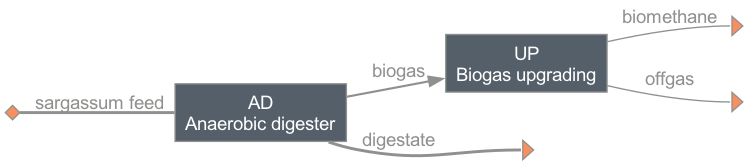

None

In [151]:
import importlib, biosteam as bst
from IPython.display import display

import sabre.chemicals as chem
import sabre.units.ad as ad
import sabre.units.biogas_upgrading as up
import sabre.systems.ad_biogas_system as adb

importlib.reload(chem)
importlib.reload(ad)
importlib.reload(up)
importlib.reload(adb)

bst.main_flowsheet.clear()
chem.create_chemicals()

sys = adb.create_ad_biogas_system(quality="pelagic_high_quality")
sys.simulate()
sys.show()

F = bst.main_flowsheet.stream
print("Raw biogas CH4 kg/hr:", F.biogas.imass["Methane"])
print("Raw biogas CO2 kg/hr:", F.biogas.imass["CarbonDioxide"])
print("Biomethane CH4 kg/hr:", F.biomethane.imass["Methane"])
print("Biomethane CO2 kg/hr:", F.biomethane.imass["CarbonDioxide"])
print("Offgas CH4 kg/hr:", F.offgas.imass["Methane"])
print("Offgas CO2 kg/hr:", F.offgas.imass["CarbonDioxide"])

display(sys.diagram(format="png"))


In [161]:
import importlib, biosteam as bst
import sabre.systems.ad_biogas_system as sysmod
import sabre.units.ad as ad
import sabre.chemicals as chem

importlib.reload(ad); importlib.reload(sysmod); importlib.reload(chem)
bst.main_flowsheet.clear()
chem.create_chemicals()

sys = sysmod.create_ad_biogas_system("pelagic_high_quality")
sys.simulate(design_and_cost=True)

AD = sys.units[0]
print(AD.design_results)
print("base_volume_m3:", AD.base_volume_m3)
print("base_capex_usd:", AD.base_capex_usd)
print("purchase/baseline costs:", getattr(AD, "baseline_purchase_costs", None) or AD.purchase_costs)



{'Slurry flow (m3/hr)': 625.0, 'HRT (days)': 25.0, 'Headspace frac': 0.15, 'Digester volume (m3)': 431249.99999999994, 'Annual maintenance ($/yr)': 4312499.999999999}
base_volume_m3: 2779.92
base_capex_usd: 1796981.4
purchase/baseline costs: {'Anaerobic digester': 37064800.58624659}


In [168]:
AD = sys.units[0]
print("base_volume_m3:", AD.base_volume_m3)
print("base_capex_usd:", AD.base_capex_usd)

base_volume_m3: 2779.92
base_capex_usd: 1796981.4


In [3]:
import importlib, biosteam as bst
import sabre.units.ad as ad
import sabre.systems.ad_biogas_system as sysmod
import sabre.chemicals as chem

importlib.reload(ad)
importlib.reload(sysmod)
importlib.reload(chem)

bst.main_flowsheet.clear()
chem.create_chemicals()

sys = sysmod.create_ad_biogas_system("pelagic_high_quality")
sys.simulate(design_and_cost=True)

AD = sys.units[0]
print("Baseline purchase:", AD.baseline_purchase_costs)
print("F_BM dict:", AD.F_BM)
print("Installed cost:", AD.installed_cost)


Baseline purchase: {'Anaerobic digester': 37064800.58624659}
F_BM dict: {'Anaerobic digester': 1.5}
Installed cost: 55597200.879369885


In [4]:
k = list(AD.baseline_purchase_costs.keys())[0]
print("Cost key:", repr(k))
print("F_BM lookup:", AD.F_BM.get(k, None))

Cost key: 'Anaerobic digester'
F_BM lookup: 1.5


In [5]:
AD = sys.units[0]
print("Instance class:", type(AD))
print("Class F_BM:", type(AD).F_BM)
print("Instance F_BM:", AD.F_BM)


Instance class: <class 'sabre.units.ad.AnaerobicDigester'>
Class F_BM: {'Anaerobic digester': 1.5}
Instance F_BM: {'Anaerobic digester': 1.5}


In [10]:
import importlib, biosteam as bst

# --- reload your modules so edits are picked up ---
import sabre.chemicals as chem
import sabre.systems.ad_biogas_system as sysmod
import sabre.units.ad as adunit
import sabre.units.biogas_upgrading as upunit

importlib.reload(chem)
importlib.reload(adunit)
importlib.reload(upunit)
importlib.reload(sysmod)

# --- clear flowsheet registry (prevents "replaced in registry" spam) ---
bst.main_flowsheet.clear()

# --- build & run ---
chem.create_chemicals()
sys = sysmod.create_ad_biogas_system(quality="pelagic_high_quality")

# IMPORTANT: design_and_cost=True so _design/_cost runs
sys.simulate(design_and_cost=True)
sys.show()

F = bst.main_flowsheet.stream
AD, UP = sys.units  # assumes path=(AD, UP)

print("\n=== MASS FLOWS (kg/hr) ===")
print("Raw biogas CH4:", float(F.biogas.imass["Methane"]))
print("Raw biogas CO2:", float(F.biogas.imass["CarbonDioxide"]))
print("Biomethane CH4:", float(F.biomethane.imass["Methane"]))
print("Biomethane CO2:", float(F.biomethane.imass["CarbonDioxide"]))
print("Offgas CH4:", float(F.offgas.imass["Methane"]))
print("Offgas CO2:", float(F.offgas.imass["CarbonDioxide"]))

# --- performance checks ---
ch4_in = float(F.biogas.imass["Methane"])
ch4_out = float(F.biomethane.imass["Methane"])
co2_out = float(F.biomethane.imass["CarbonDioxide"])
biometh_molfrac_ch4 = float(F.biomethane.imol["Methane"]) / float(F.biomethane.F_mol)

print("\n=== PERFORMANCE CHECKS ===")
print("CH4 recovery (mass):", ch4_out / ch4_in if ch4_in > 0 else None)
print("Biomethane CH4 mol%:", biometh_molfrac_ch4 * 100)

# --- design + utilities ---
print("\n=== DESIGN RESULTS ===")
print("AD design keys:", list(AD.design_results.keys()))
print("UP design keys:", list(UP.design_results.keys()))
print("AD digester volume (m3):", AD.design_results.get("Digester volume (m3)"))
print("UP raw biogas flow (Nm3/h):", UP.design_results.get("Raw biogas flow (Nm3/h)"))

print("\n=== UTILITIES ===")
print("UP power (kW):", float(UP.power_utility.rate))

# --- costs ---
print("\n=== COSTING ===")
print("AD baseline purchase ($):", AD.baseline_purchase_costs)
print("AD installed cost ($):", float(AD.installed_cost))
print("UP baseline purchase ($):", UP.baseline_purchase_costs)
print("UP installed cost ($):", float(UP.installed_cost))

# If you set F_BM on UP, verify it's applied:
print("\n=== F_BM CHECK ===")
print("AD F_BM:", AD.F_BM)
print("UP F_BM:", UP.F_BM)

# --- diagram (quick visual sanity check) ---
from IPython.display import display
display(sys.diagram(format="png"))


AttributeError: 'NoneType' object has no attribute 'simulate'